# Анализ работы службы поддержки

# Описание исследования

В нашем распоряжении данные о работе службы поддержки одного из сервисов.

# Цель исследования

Провести исследовательский анализ данных.

# Задачи исследования

1. Оценить представленные данные.
2. Выполнить предобработку данных.
3. Провести исследовательский анализ данных.

# Исходные данные

В нашем распоряжении два датасета. Файл count_sla.xlsx хранит информацию тикетах и SLA службы поддержки. Файл operator_performance.xlsx - хранит информацию о производительности операторов службы поддержки.

Структура файла count_sla.xlsx:

    created_at - дата создания тикета;
    count_of_tickets - количество тикетов;
    sla - выполнение SLA данного тикета операторами службы поддержки в долях от единицы.

Структура файла operator_performance.xlsx:

    name - имя оператора;
    month - месяц работы оператора;
    count_of_tickets - количество тикетов обработанных данным оператором за месяц.

# Данное исследование разделим на несколько частей

## Загрузка данных и подготовка их к анализу

### Импортируем и установим необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#### Установим библиотеку openpyxl

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


### Cчитаем данные из файлов excel в датафрейм и сохраним в переменные count_sla и operator_performance

In [3]:
try:
    count_sla = pd.read_excel(r'C:\Users\Равиль\Проекты для портфолио\6. Тестовое задание 1\count_sla.xlsx',\
                              engine='openpyxl')
    print("✅ Файл загружен с локального пути")
except:
    try:
        count_sla = pd.read_excel("https://drive.google.com/uc?export=download&id=1K4RZclecwyR7XXZZQM6HYibyldT_lwPF",\
                              engine='openpyxl')
    except:
        try:
            count_sla = pd.read_excel("/content/drive/MyDrive/count_sla.xlsx", engine='openpyxl')
            print("✅ Файл загружен из Google Colab")
        except Exception as e:
            print("❌ Ошибка загрузки файла:", e)

✅ Файл загружен с локального пути


In [4]:
try:
    operator_performance = pd.read_excel(r'C:\Users\Равиль\Проекты для портфолио\6. Тестовое задание 1\\' +
                                         r'operator_performance.xlsx', engine='openpyxl')
    print("✅ Файл загружен с локального пути")
except:
    try:
        operator_performance = \
        pd.read_excel("https://drive.google.com/uc?export=download&id=1VgWpAHjwvpWOHk7_TjUT7YR-c4HGOPAA",\
                      engine='openpyxl')
    except:
        try:
            operator_performance = pd.read_excel("/content/drive/MyDrive/operator_performance.xlsx", engine='openpyxl')
            print("✅ Файл загружен из Google Colab")
        except Exception as e:
            print("❌ Ошибка загрузки файла:", e)

✅ Файл загружен с локального пути


### Изучим общую информацию о датафрейме count_sla

In [5]:
count_sla.head(10)

,created_at,count_of_tickets,sla
0,2022-01-01 06:33:34,1,0.0
1,2022-01-01 08:14:39,1,1.0
2,2022-01-01 09:00:31,1,1.0
3,2022-01-01 09:24:38,1,1.0
4,2022-01-01 09:49:39,1,1.0
5,2022-01-01 10:30:10,1,1.0
6,2022-01-01 11:38:57,1,1.0
7,2022-01-01 12:32:27,1,1.0
8,2022-01-01 12:49:12,1,1.0
9,2022-01-01 13:33:48,1,1.0


### Изучим общую информацию о датафрейме operator_performance

In [6]:
operator_performance.head(10)

,name,month,count_of_tickets
0,Катя,2024-10-01,1005
1,Катя,2024-11-01,803
2,Катя,2024-12-01,619
3,Лёша,2024-01-01,395
4,Лёша,2024-02-01,500
5,Лёша,2024-03-01,488
6,Лёша,2024-04-01,954
7,Лёша,2024-05-01,863
8,Лёша,2024-06-01,1193
9,Лёша,2024-07-01,1032


### Выведем основную информацию о датафреймах count_sla и operator_performance

In [7]:
count_sla.info()
print()
operator_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282981 entries, 0 to 282980
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   created_at        282981 non-null  datetime64[ns]
 1   count_of_tickets  282981 non-null  int64         
 2   sla               282981 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 6.5 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              140 non-null    object        
 1   month             140 non-null    datetime64[ns]
 2   count_of_tickets  140 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.4+ KB


### Выведем общее количество строк в датафреймах count_sla и operator_performance

In [8]:
count_rows_sla = len(count_sla)
count_rows_operators = len(operator_performance)

print(count_rows_sla)
print()
print(count_rows_operators)

282981

140


### Выводы по 1 разделу

Таблица count_sla содержит 3 столбца в которых имеются дата и время, целые и вещественные числа.

1. Типом данных в столбце created_at является дата и время.
2. Типом данных в столбце count_of_tickets являются целые числа.
3. Типом данных в столбце sla являются вещественные числа.

Таблица operator_performance содержит 3 столбца в которых имеются строки, дата и время и вещественные числа.

1. Типом данных в столбце name являются строки.
2. Типом данных в столбце month является дата и время.
3. Типом данных в столбце count_of_tickets являются целые числа.

В столбце sla таблицы count_sla данные представлены в виде вещестсвенных чисел в доли от единицы. Для удобного представления имеет смысл добавить отдельный столбец с отображение значения sla в процентах.

## Предобработка данных

### Изучение и обработка пропусков

#### Опеределим сколько всего есть пропущенных значений в каждом столбце в датафреймах count_sla и operator_performance

In [9]:
print(count_sla.isna().sum().sort_values(ascending=False))
print()
print(operator_performance.isna().sum().sort_values(ascending=False))

created_at          0
count_of_tickets    0
sla                 0
dtype: int64

name                0
month               0
count_of_tickets    0
dtype: int64


### Изучение дубликатов в датафрейме

#### Проверим есть ли явные дубликаты в датафреймах count_sla и operator_performance

In [10]:
print(count_sla.duplicated().sum())
print()
print(operator_performance.duplicated().sum())

0

0


#### Оценим есть ли дубликаты в датах создания тикета столбца created_at таблицы count_sla

In [11]:
print(count_sla['created_at'].duplicated().sum())

0


#### Оценим есть ли дубликаты в сочетания имени оператора и месяца работы оператора столбцов name и month таблицы operator_performance

In [12]:
operator_performance.duplicated(subset=['name', 'month']).sum()

0

### Добавление новых столбцов

#### Добавим в таблицу count_sla новый столбец sla_percent, обозначающий выполнение SLA данного тикета операторами службы поддержки в процентах

In [13]:
count_sla['sla_percent'] = count_sla['sla']*100
count_sla.head(10)

,created_at,count_of_tickets,sla,sla_percent
0,2022-01-01 06:33:34,1,0.0,0.0
1,2022-01-01 08:14:39,1,1.0,100.0
2,2022-01-01 09:00:31,1,1.0,100.0
3,2022-01-01 09:24:38,1,1.0,100.0
4,2022-01-01 09:49:39,1,1.0,100.0
5,2022-01-01 10:30:10,1,1.0,100.0
6,2022-01-01 11:38:57,1,1.0,100.0
7,2022-01-01 12:32:27,1,1.0,100.0
8,2022-01-01 12:49:12,1,1.0,100.0
9,2022-01-01 13:33:48,1,1.0,100.0


#### Добавим в таблицу count_sla новый столбец month_of_created, обозначающий месяц создания тикета

In [14]:
count_sla['month_of_created'] = pd.to_datetime(count_sla['created_at']).dt.month
count_sla.head(10)

,created_at,count_of_tickets,sla,sla_percent,month_of_created
0,2022-01-01 06:33:34,1,0.0,0.0,1
1,2022-01-01 08:14:39,1,1.0,100.0,1
2,2022-01-01 09:00:31,1,1.0,100.0,1
3,2022-01-01 09:24:38,1,1.0,100.0,1
4,2022-01-01 09:49:39,1,1.0,100.0,1
5,2022-01-01 10:30:10,1,1.0,100.0,1
6,2022-01-01 11:38:57,1,1.0,100.0,1
7,2022-01-01 12:32:27,1,1.0,100.0,1
8,2022-01-01 12:49:12,1,1.0,100.0,1
9,2022-01-01 13:33:48,1,1.0,100.0,1


#### Добавим в таблицу count_sla новый столбец year_of_created, обозначающий год создания тикета

In [15]:
count_sla['year_of_created'] = pd.to_datetime(count_sla['created_at']).dt.year
count_sla.head(10)

,created_at,count_of_tickets,sla,sla_percent,month_of_created,year_of_created
0,2022-01-01 06:33:34,1,0.0,0.0,1,2022
1,2022-01-01 08:14:39,1,1.0,100.0,1,2022
2,2022-01-01 09:00:31,1,1.0,100.0,1,2022
3,2022-01-01 09:24:38,1,1.0,100.0,1,2022
4,2022-01-01 09:49:39,1,1.0,100.0,1,2022
5,2022-01-01 10:30:10,1,1.0,100.0,1,2022
6,2022-01-01 11:38:57,1,1.0,100.0,1,2022
7,2022-01-01 12:32:27,1,1.0,100.0,1,2022
8,2022-01-01 12:49:12,1,1.0,100.0,1,2022
9,2022-01-01 13:33:48,1,1.0,100.0,1,2022


#### Добавим в таблицу count_sla новый столбец month_year_of_created, обозначающий месяц и год создания тикета

In [16]:
count_sla['month_year_of_created'] = count_sla['month_of_created'].astype(str).str.zfill(2) + \
                          '-' + count_sla['year_of_created'].astype(str)
count_sla.head(10)

,created_at,count_of_tickets,sla,sla_percent,month_of_created,year_of_created,month_year_of_created
0,2022-01-01 06:33:34,1,0.0,0.0,1,2022,01-2022
1,2022-01-01 08:14:39,1,1.0,100.0,1,2022,01-2022
2,2022-01-01 09:00:31,1,1.0,100.0,1,2022,01-2022
3,2022-01-01 09:24:38,1,1.0,100.0,1,2022,01-2022
4,2022-01-01 09:49:39,1,1.0,100.0,1,2022,01-2022
5,2022-01-01 10:30:10,1,1.0,100.0,1,2022,01-2022
6,2022-01-01 11:38:57,1,1.0,100.0,1,2022,01-2022
7,2022-01-01 12:32:27,1,1.0,100.0,1,2022,01-2022
8,2022-01-01 12:49:12,1,1.0,100.0,1,2022,01-2022
9,2022-01-01 13:33:48,1,1.0,100.0,1,2022,01-2022


### Выводы по предообработке данных

1. В таблицах count_sla и operator_performance нет пропусков
2. В таблицах count_sla и operator_performance нет явных и неявных дубликатов.
3. Для удобства расчетов и последующих визаулизаций в таблице count_sla был добавлен столбец sla_percent, обозначающий выполнение SLA данного тикета операторами службы поддержки в процентах. Также были добавлены месяц month_of_created, год year_of_created и месяц и год month_year_of_created создания тикета.

## Исследовательский анализ данных

### Оценка представленных даных 

#### Установим формат представления дробных чисел с двумя значениями после запятой

In [17]:
pd.options.display.float_format = '{:.2f}'.format

#### Выведем описательную статистику по датафрейму count_sla

In [18]:
count_sla.describe()

,count_of_tickets,sla,sla_percent,month_of_created,year_of_created
count,282981.00,282981.00,282981.00,282981.00,282981.00
mean,1.03,0.73,72.81,6.78,2023.20
std,0.20,0.44,44.31,3.54,0.77
min,1.00,0.00,0.00,1.00,2022.00
25%,1.00,0.00,0.00,4.00,2023.00
50%,1.00,1.00,100.00,7.00,2023.00
75%,1.00,1.00,100.00,10.00,2024.00
max,15.00,1.00,100.00,12.00,2024.00


#### Опреределим минимальный и максимальный месяц обработки обращений операторами из таблицы operator_performance

In [19]:
operator_performance['month'].agg([min, max])

min   2024-01-01
max   2024-12-01
Name: month, dtype: datetime64[ns]

### Построение сводных таблиц

#### Построим сводную таблицу pivot_tickets методом pivot_table() со следующими столбцами:
    month_year_of_created - месяц и год создания тикета;
    year_of_created - год создания тикета;
    month_of_created - месяц создания тикета;
    count_of_tickets_sum - количество тикетов в месяц;
    sla_mean - среднее значение SLA в месяц.

In [20]:
pivot_tickets = count_sla.pivot_table(index=['month_year_of_created', 'year_of_created', 'month_of_created'], values = \
                                      ['count_of_tickets', 'sla_percent'], aggfunc = {'count_of_tickets': ['sum'], \
                                                                                   'sla_percent': ['mean']}).reset_index()
pivot_tickets.columns = ['month_year_of_created', 'year_of_created', 'month_of_created',\
                         'count_of_tickets_sum', 'sla_mean']
pivot_tickets = pivot_tickets.sort_values(by = ['year_of_created', 'month_of_created']).reset_index(drop=True)
pivot_tickets

,month_year_of_created,year_of_created,month_of_created,count_of_tickets_sum,sla_mean
0,01-2022,2022,1,4683,90.82
1,02-2022,2022,2,6141,88.77
2,03-2022,2022,3,6740,54.00
3,04-2022,2022,4,6674,75.72
4,05-2022,2022,5,5619,88.91
5,06-2022,2022,6,5060,91.43
6,07-2022,2022,7,4035,80.19
7,08-2022,2022,8,4067,84.27
8,09-2022,2022,9,4694,76.54
9,10-2022,2022,10,5842,31.12


#### Построим сводную таблицу pivot_tickets_year методом pivot_table() со следующими столбцами:
    year_of_created - год создания тикета;
    count_of_tickets_year_mean - среднее значение количества тикетов в году;
    sla_year_mean - среднее значение SLA в году.

In [21]:
pivot_tickets_year = pivot_tickets.pivot_table(index='year_of_created', values = ['count_of_tickets_sum', 'sla_mean'],\
                            aggfunc = {'count_of_tickets_sum': ['sum', 'mean'], 'sla_mean': ['mean']}).reset_index()
pivot_tickets_year.columns = ['year_of_created', 'count_of_tickets_year_mean', 'count_of_tickets_year_sum',\
                              'sla_year_mean']
pivot_tickets_year

,year_of_created,count_of_tickets_year_mean,count_of_tickets_year_sum,sla_year_mean
0,2022,5442.67,65312.00,67.38
1,2023,8839.58,106075.00,59.88
2,2024,10039.83,120478.00,89.12


#### Построим сводную таблицу pivot_operator_performance методом pivot_operator_performance() со следующими столбцами:
    name - имя оператора;
    count_of_tickets_sum - общее количество тикетов, обработанных оператором;
    count_of_tickets_mean - среднее количество тикетов в месяц, обработанных оператором.

In [22]:
pivot_operator_performance = operator_performance.pivot_table(index='name', values = ['count_of_tickets', 'month'],\
                                                              aggfunc = {'count_of_tickets': ['sum', 'mean'], 'month': \
                                                                         ['count']}).reset_index()
pivot_operator_performance.columns = ['name', 'count_of_tickets_mean', 'count_of_tickets_sum', 'count_month']
pivot_operator_performance = pivot_operator_performance[['name', 'count_of_tickets_sum', 'count_month',\
                                                         'count_of_tickets_mean']]
pivot_operator_performance = pivot_operator_performance.sort_values(by = ['count_month', 'count_of_tickets_mean'], \
                                                                    ascending = False).reset_index(drop=True)
pivot_operator_performance

,name,count_of_tickets_sum,count_month,count_of_tickets_mean
0,Настя,20976.00,12,1748.00
1,Лера,18670.00,12,1555.83
2,Ксюша,16592.00,12,1382.67
3,Таня,14493.00,12,1207.75
4,Наташа,13297.00,12,1108.08
5,Оксана,13290.00,12,1107.50
6,Лёша,10144.00,12,845.33
7,Ира,9473.00,12,789.42
8,Катерина,11044.00,10,1104.40
9,Серёжа,7287.00,10,728.70


### Построение графиков

#### Построим график распределения количества тикетов по месяцам и годам

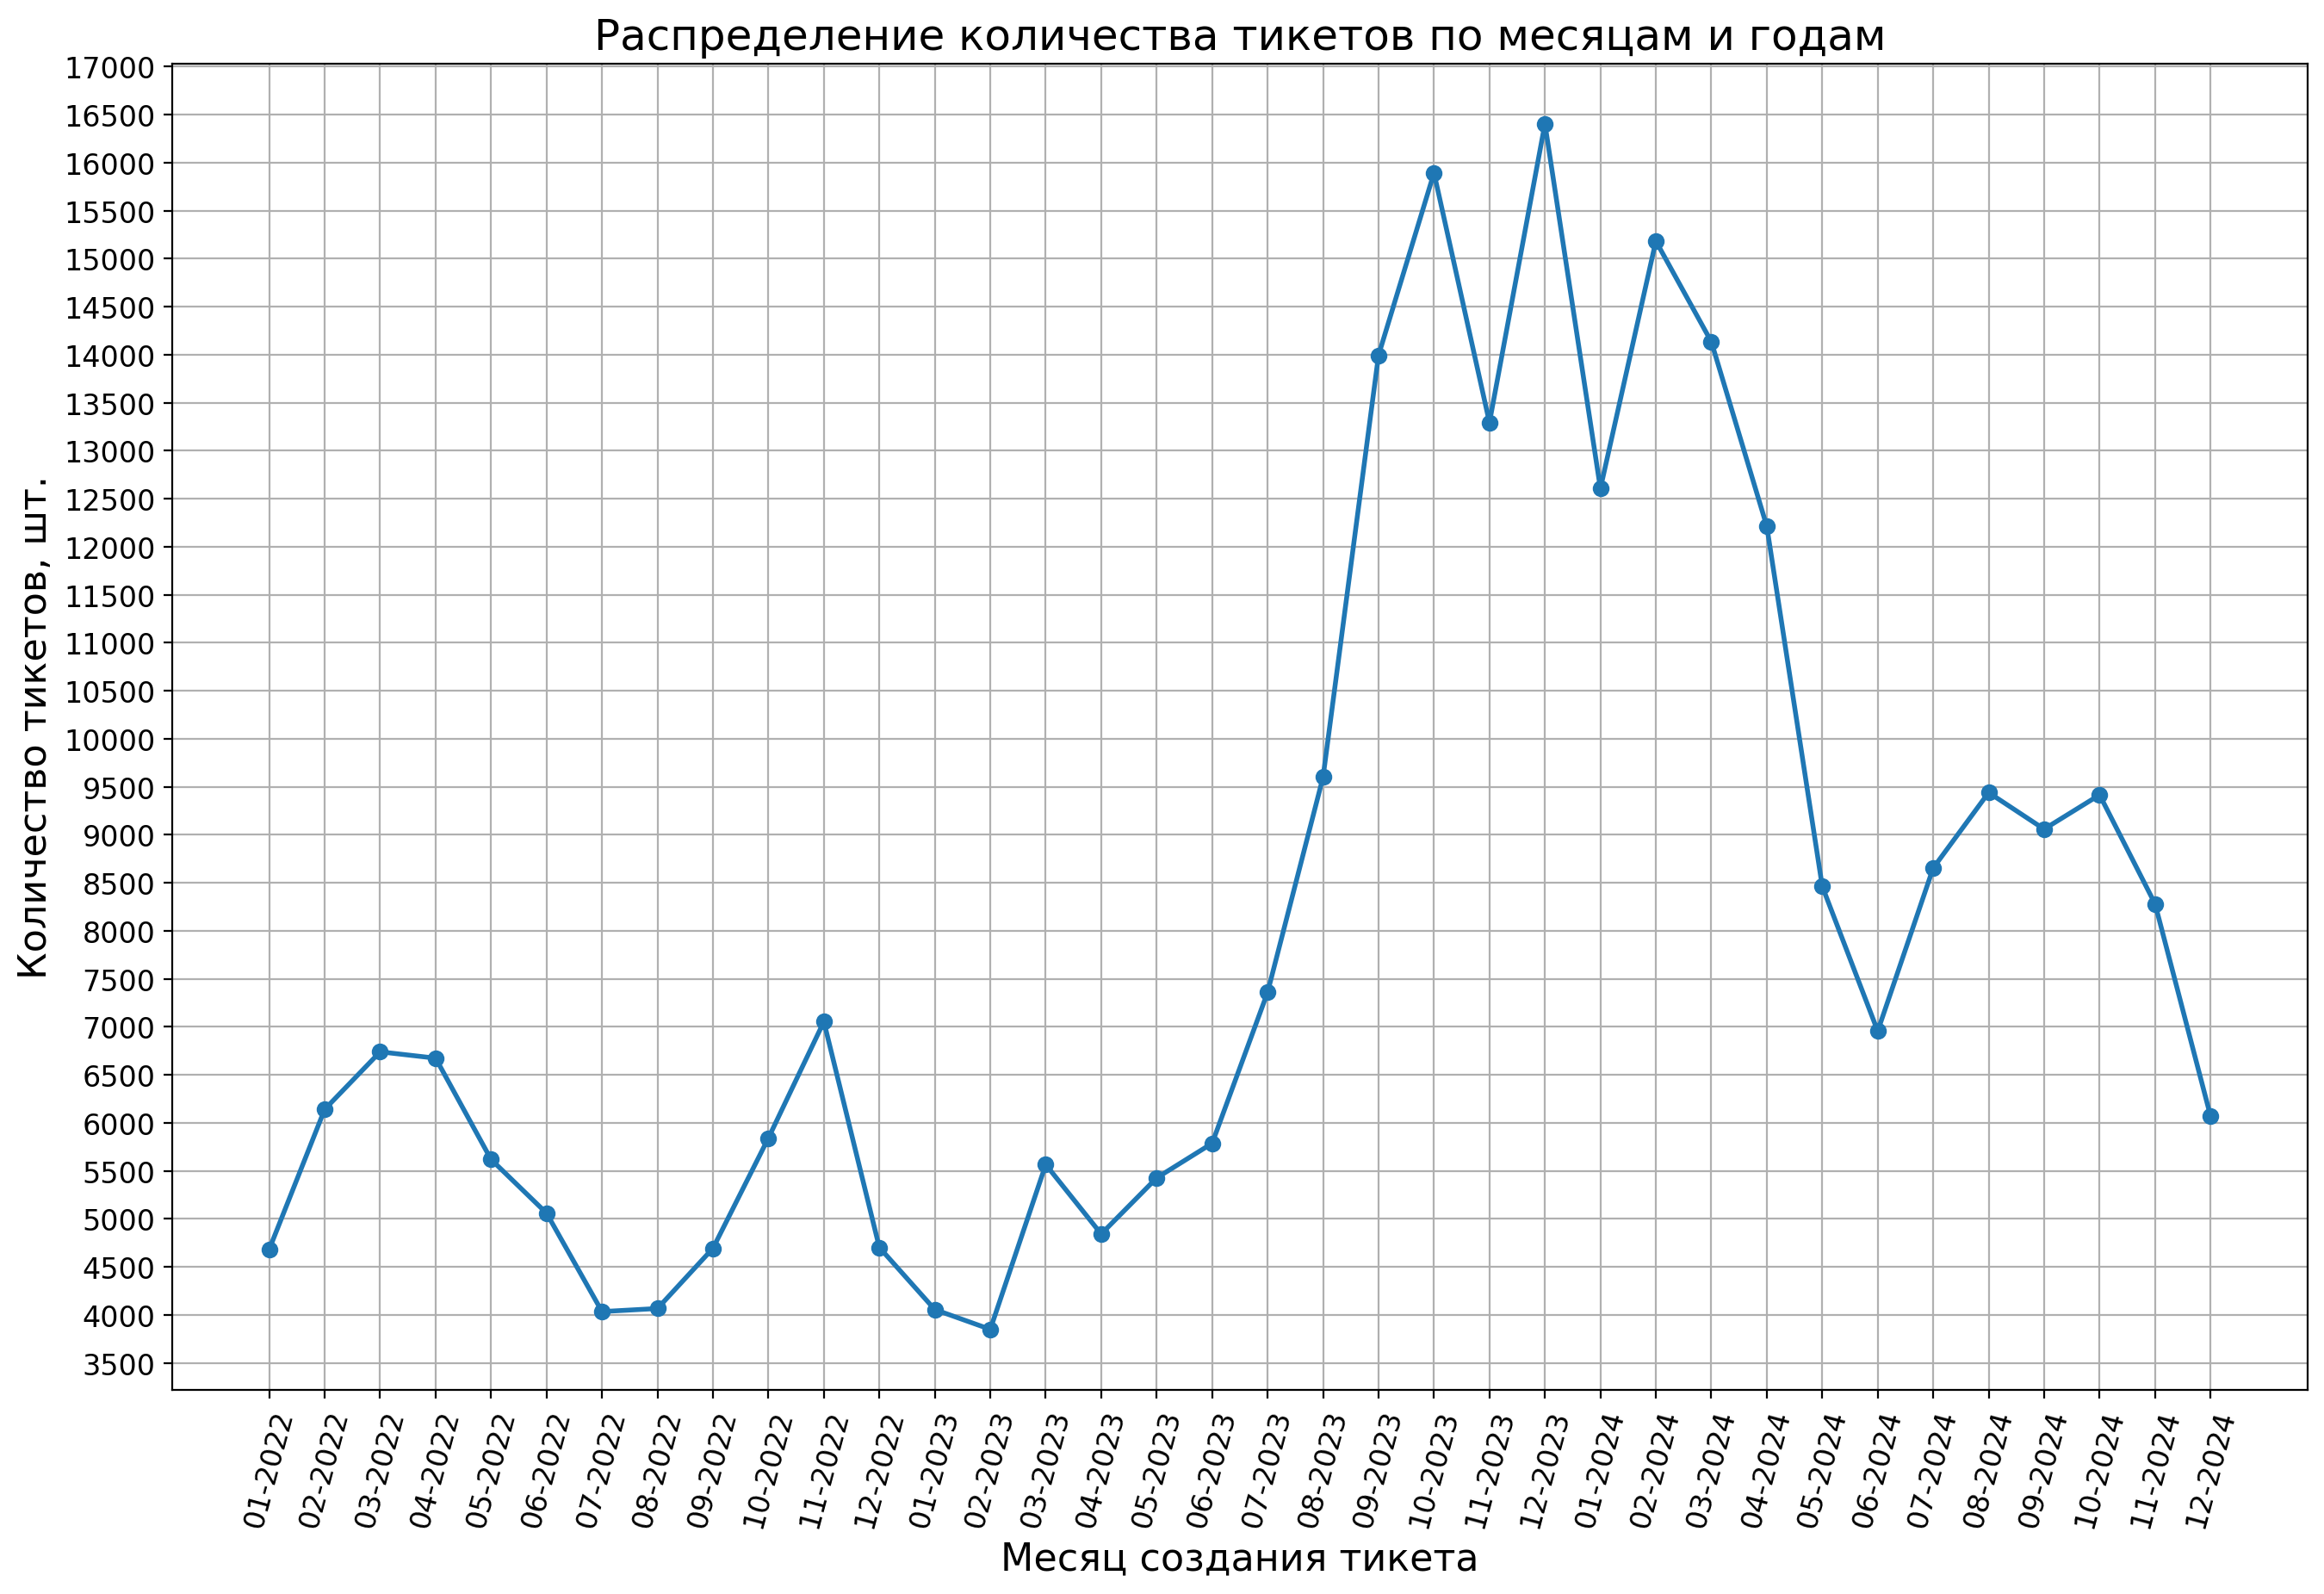

In [23]:
plt.figure(figsize=(16, 10), dpi=200)
plt.plot(pivot_tickets['month_year_of_created'], pivot_tickets['count_of_tickets_sum'], marker='o', linestyle='-',\
         linewidth=2)
plt.title('Распределение количества тикетов по месяцам и годам', fontsize=18)
plt.xlabel('Месяц создания тикета', fontsize=16)
plt.ylabel('Количество тикетов, шт.', fontsize=16)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(500))
plt.xticks(rotation=75)
plt.gca().grid(True)
plt.show()

#### Построим график распределения среднего значения SLA по месяцам и годам

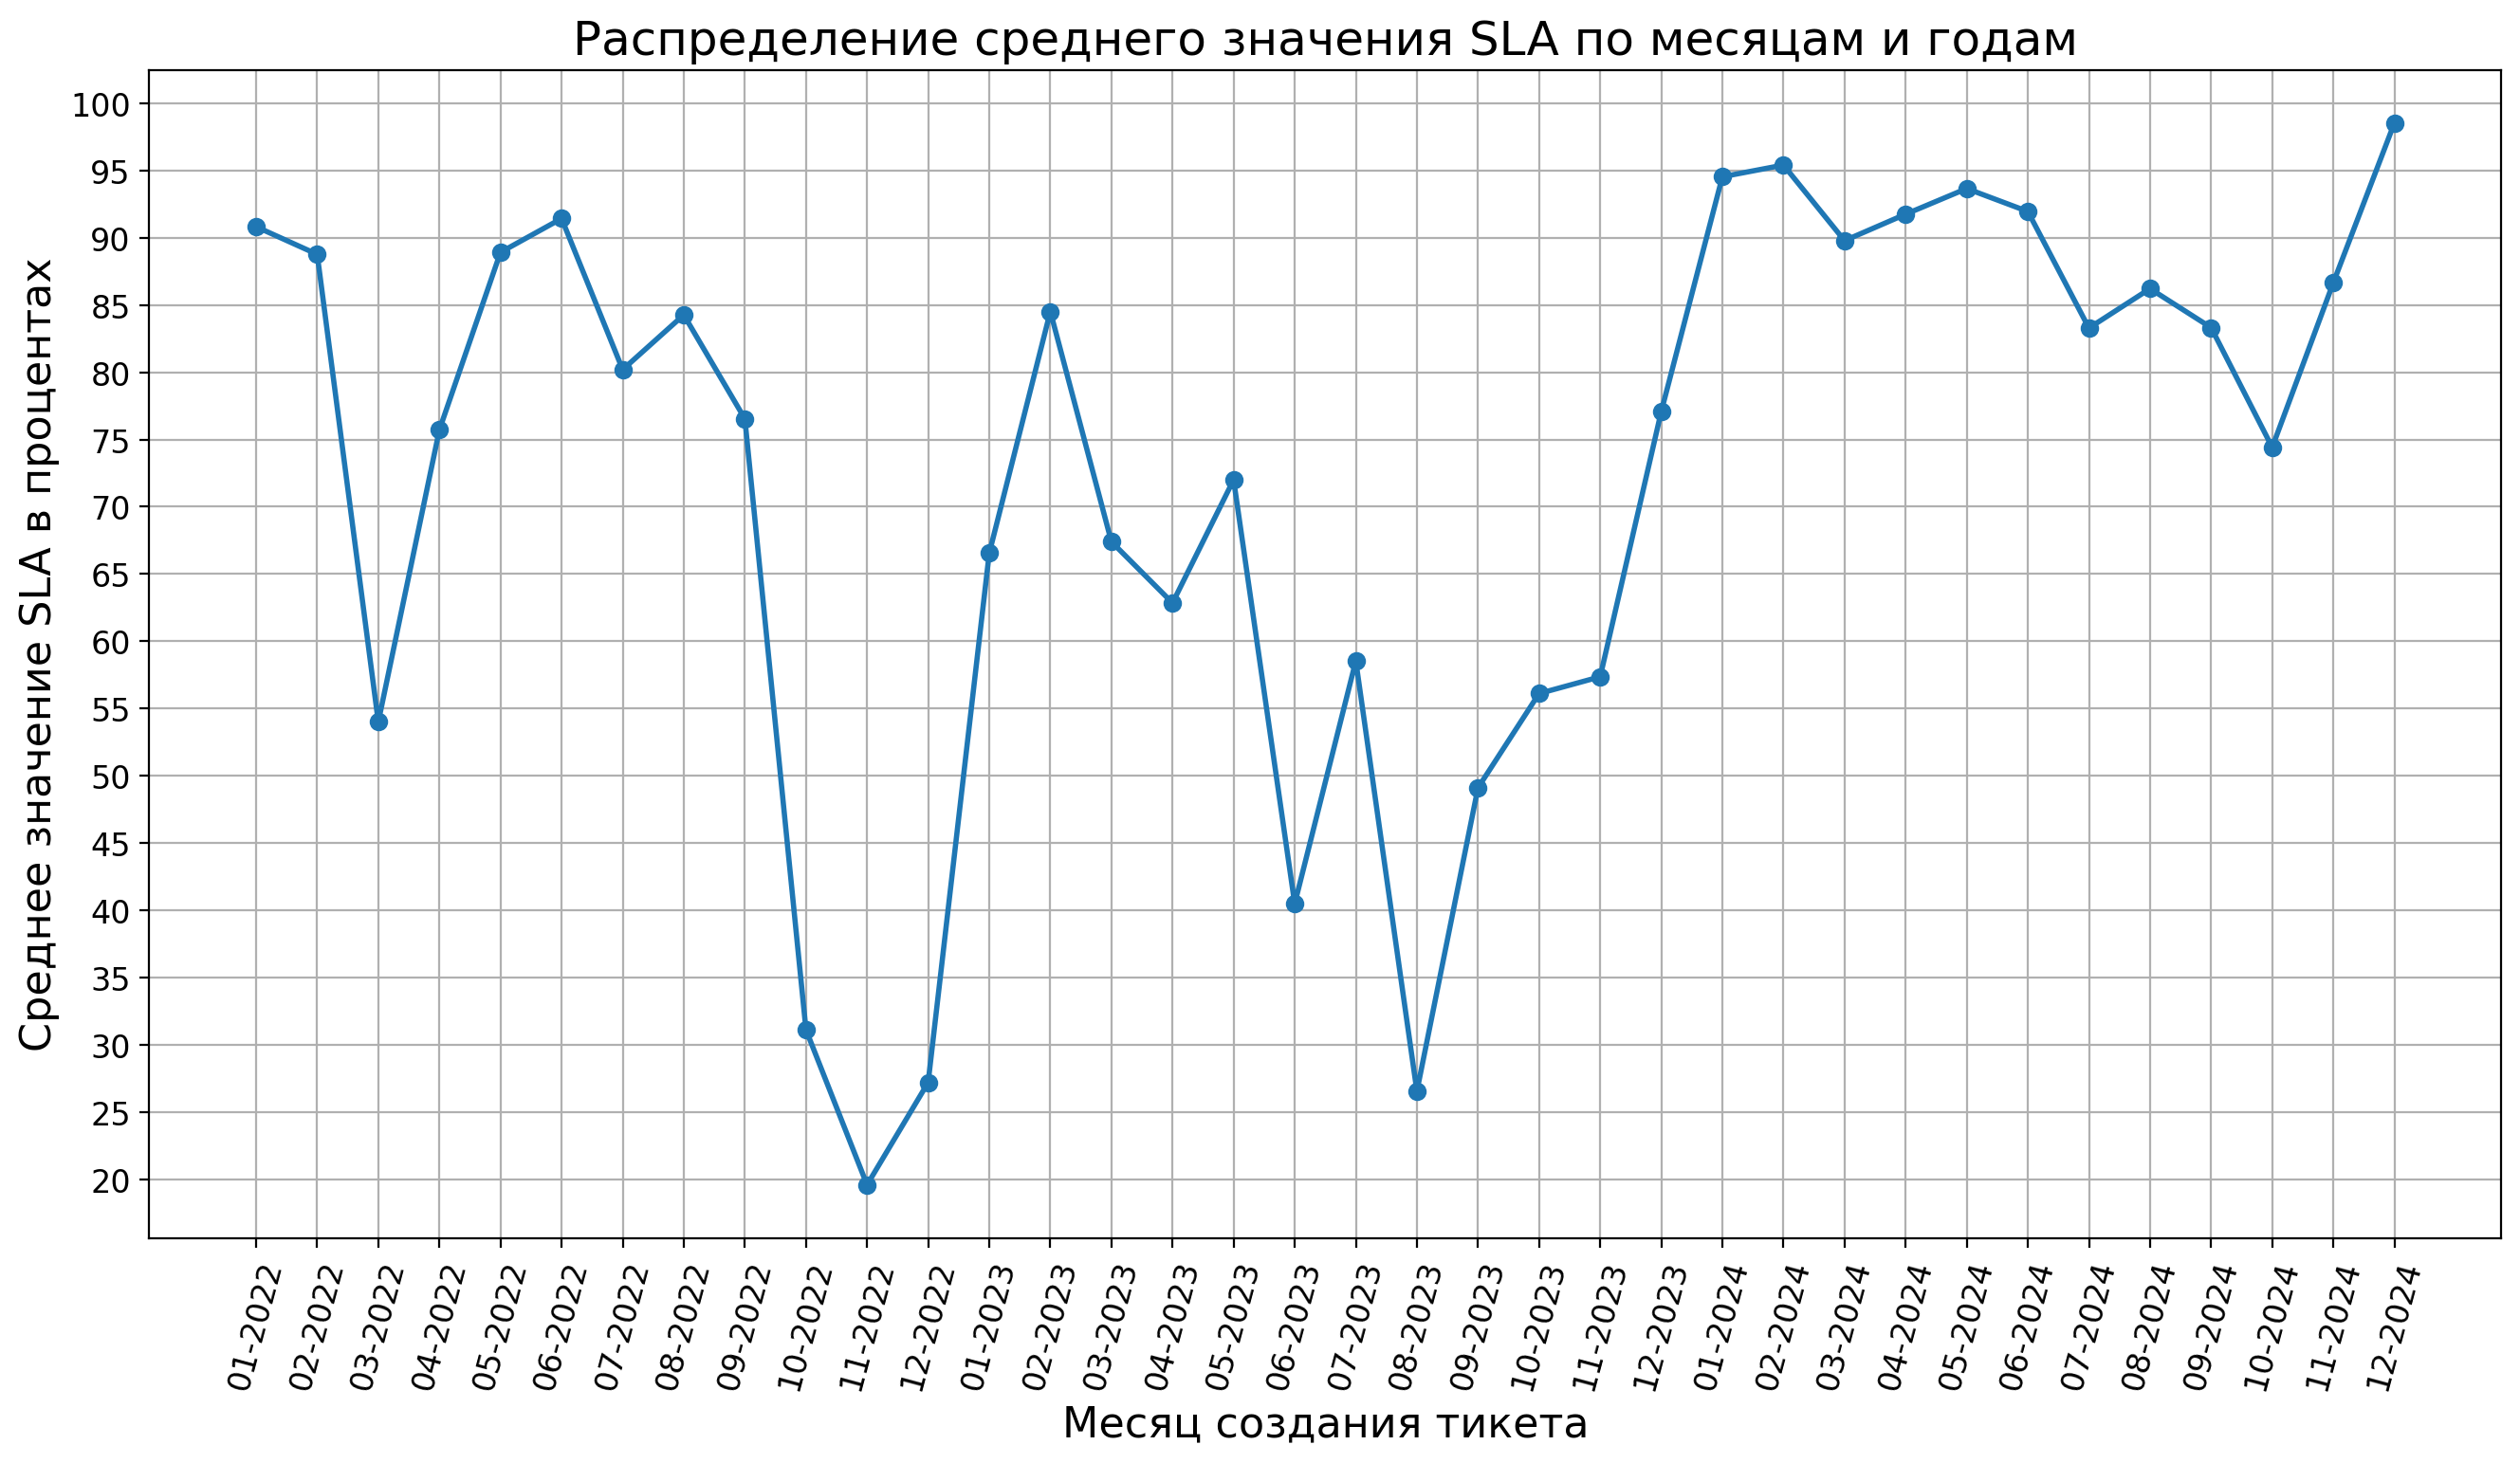

In [24]:
plt.figure(figsize=(16, 8), dpi=200)
plt.plot(pivot_tickets['month_year_of_created'], pivot_tickets['sla_mean'], marker='o', linestyle='-',\
         linewidth=2)
plt.title('Распределение среднего значения SLA по месяцам и годам', fontsize=18)
plt.xlabel('Месяц создания тикета', fontsize=16)
plt.ylabel('Среднее значение SLA в процентах', fontsize=16)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.xticks(rotation=75)
plt.gca().grid(True)
plt.show()

#### Построим график распределения среднего количества тикетов годам

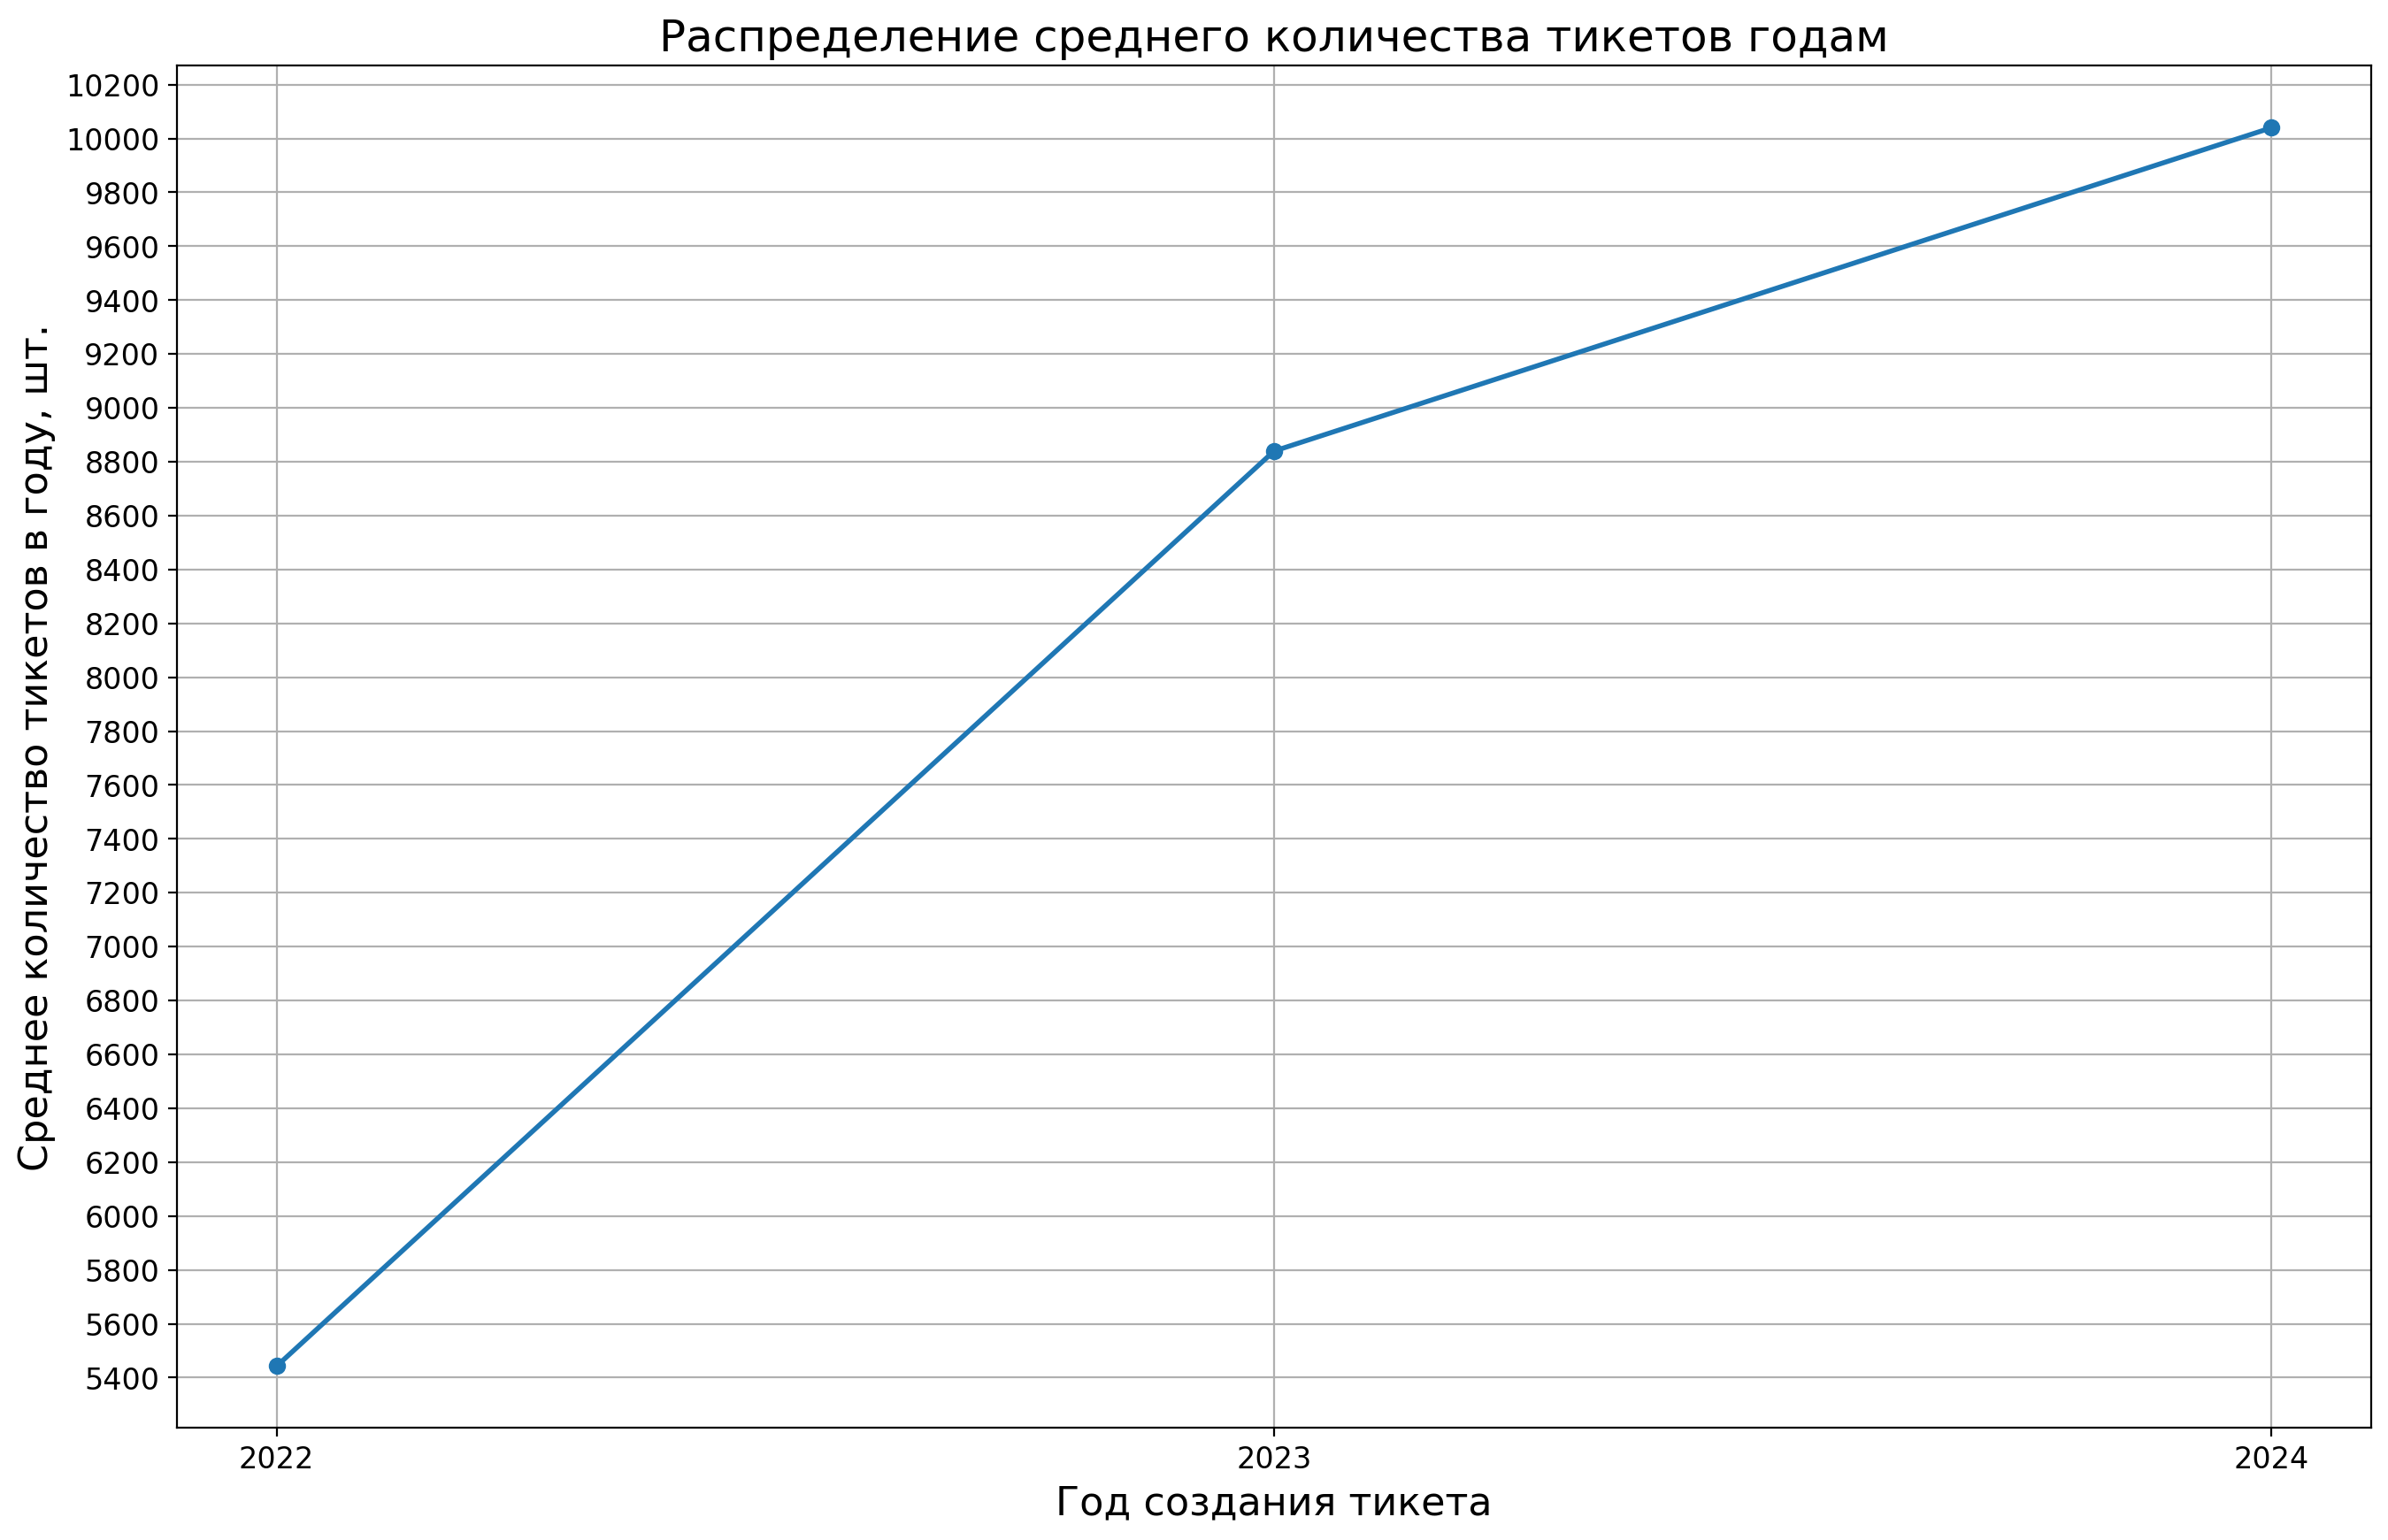

In [25]:
plt.figure(figsize=(16, 10), dpi=200)
plt.plot(pivot_tickets_year['year_of_created'], pivot_tickets_year['count_of_tickets_year_mean'], marker='o', \
         linestyle='-', linewidth=2)
plt.title('Распределение среднего количества тикетов годам', fontsize=18)
plt.xlabel('Год создания тикета', fontsize=16)
plt.ylabel('Среднее количество тикетов в году, шт.', fontsize=16)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(200))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().grid(True)
plt.show()

#### Построим график распределения реднего значения SLA по годам

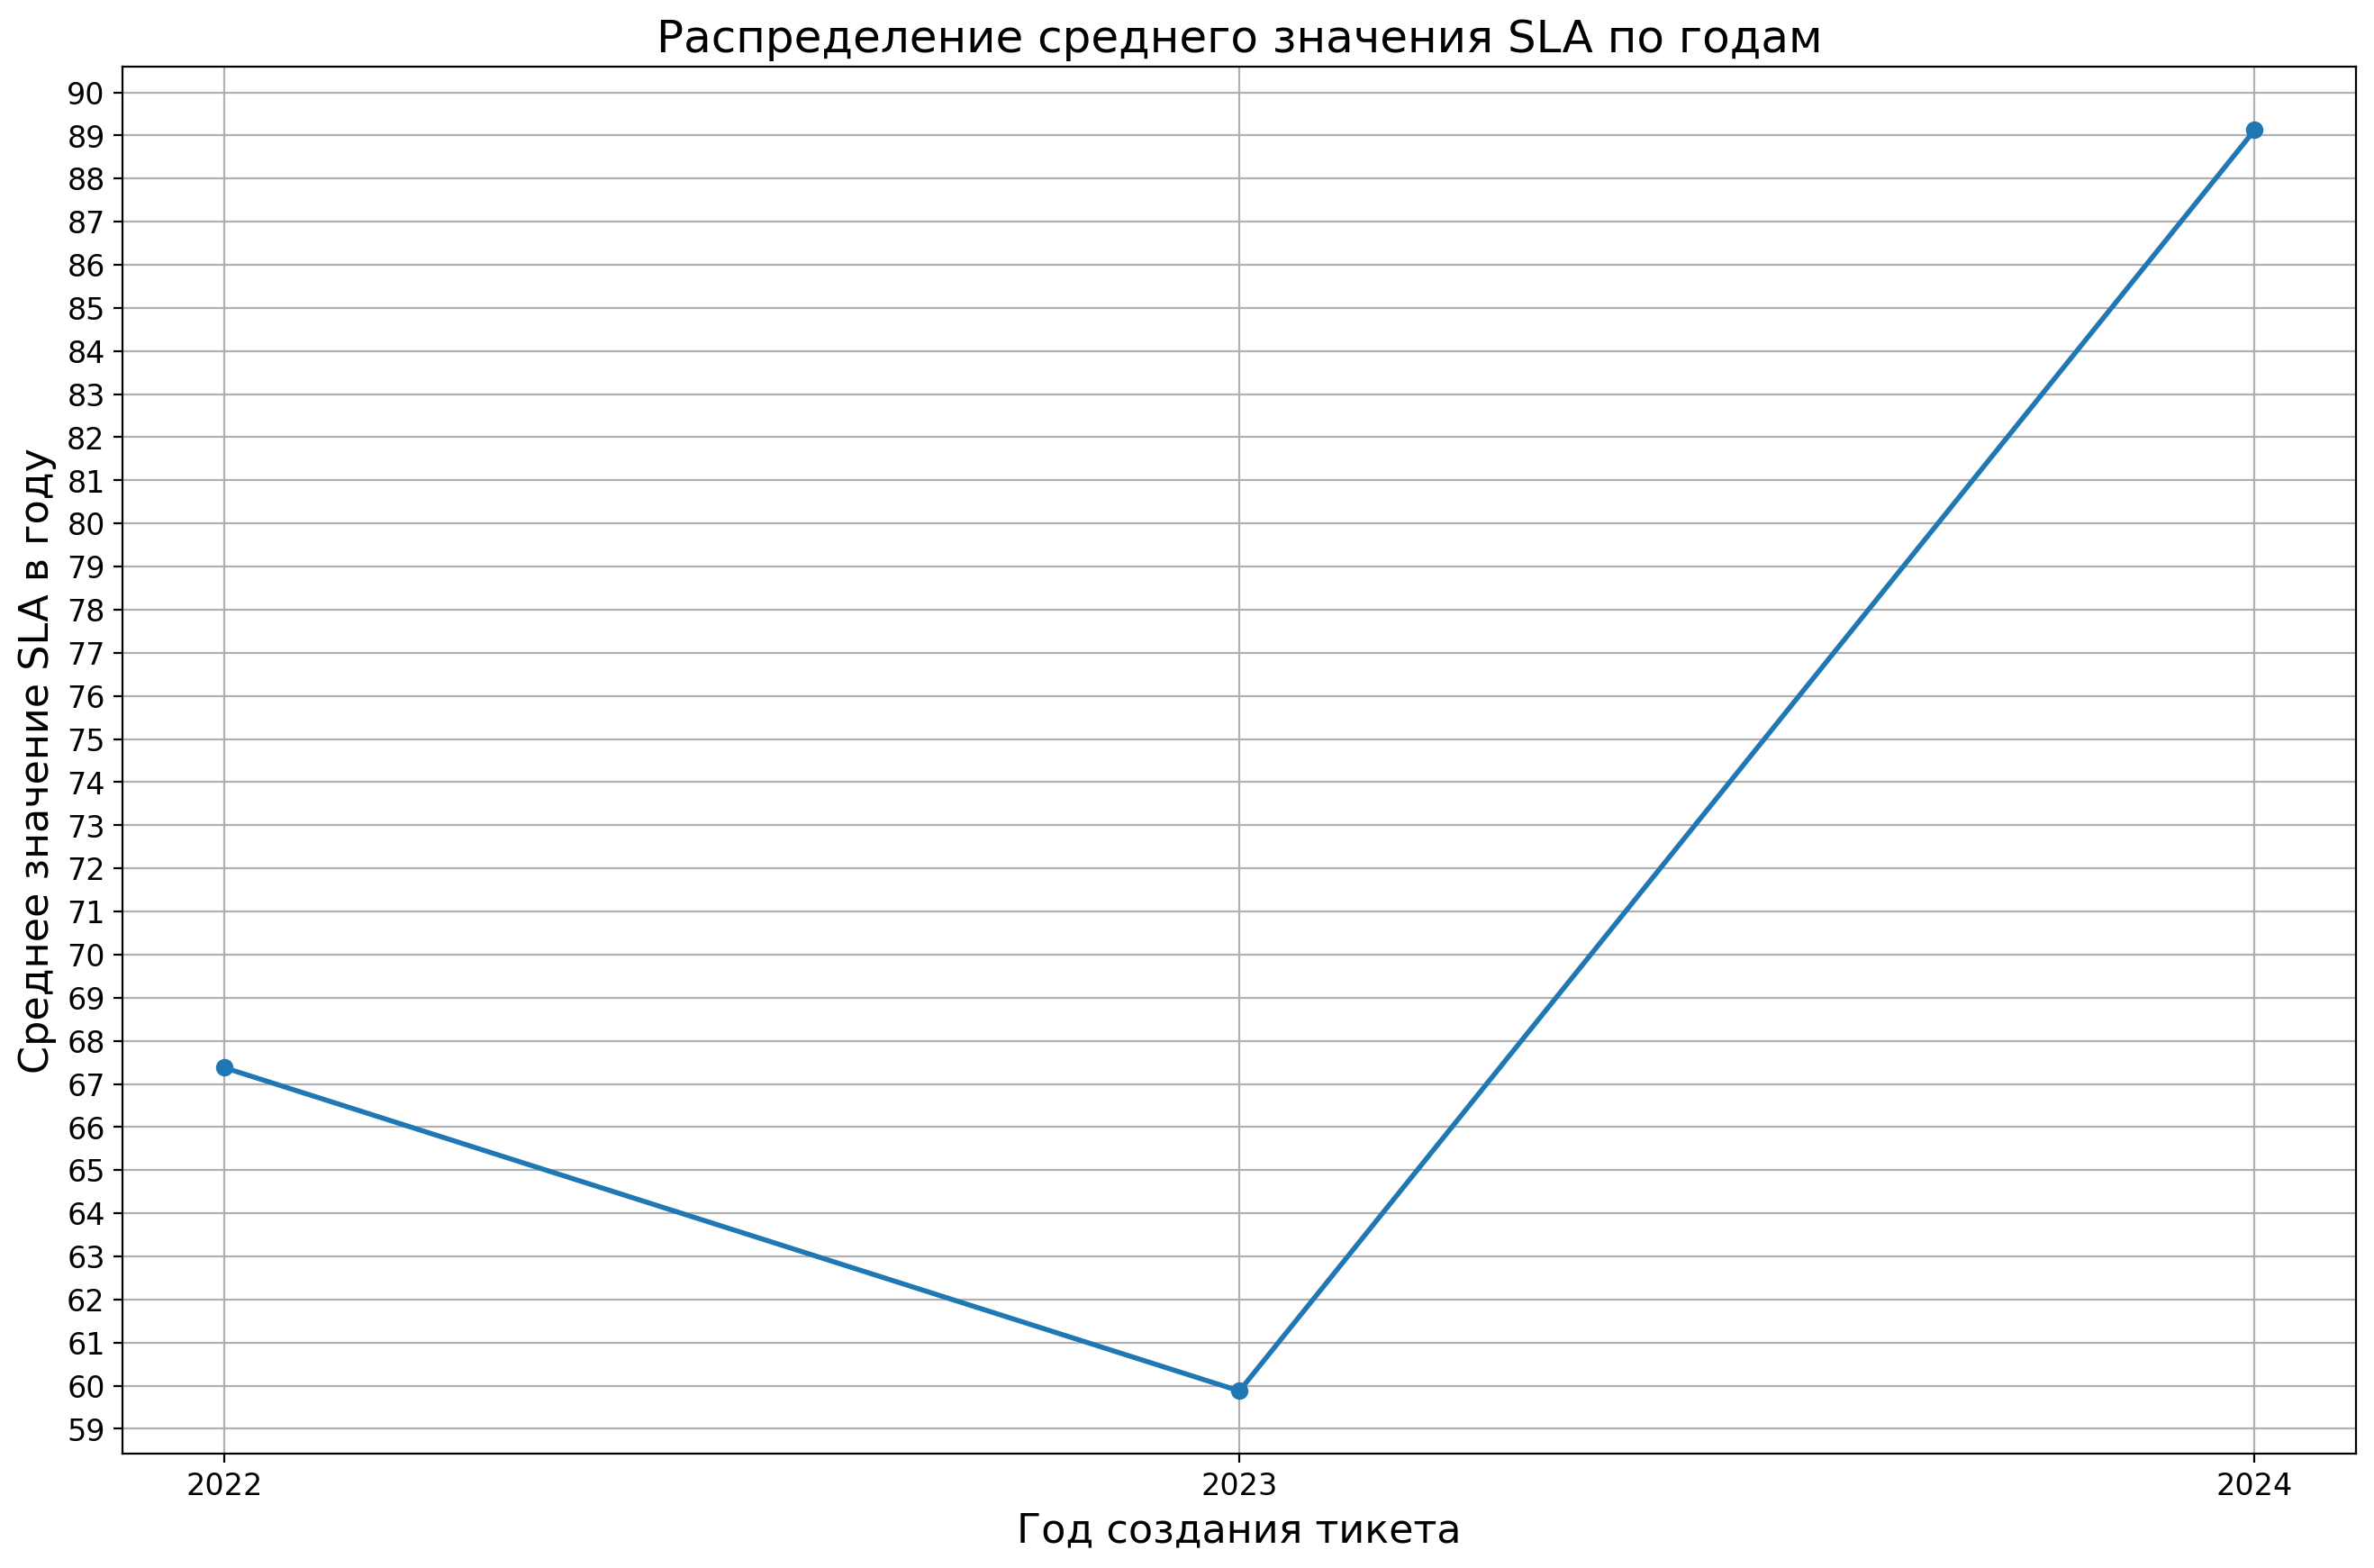

In [26]:
plt.figure(figsize=(16, 10), dpi=200)
plt.plot(pivot_tickets_year['year_of_created'], pivot_tickets_year['sla_year_mean'], marker='o', \
         linestyle='-', linewidth=2)
plt.title('Распределение среднего значения SLA по годам', fontsize=18)
plt.xlabel('Год создания тикета', fontsize=16)
plt.ylabel('Среднее значение SLA в году', fontsize=16)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(1))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().grid(True)
plt.show()

### Корелляция между нагрузкой и SLA

#### Построим диаграмму рассеяния зависимости SLA от количества тикетов по месяцам

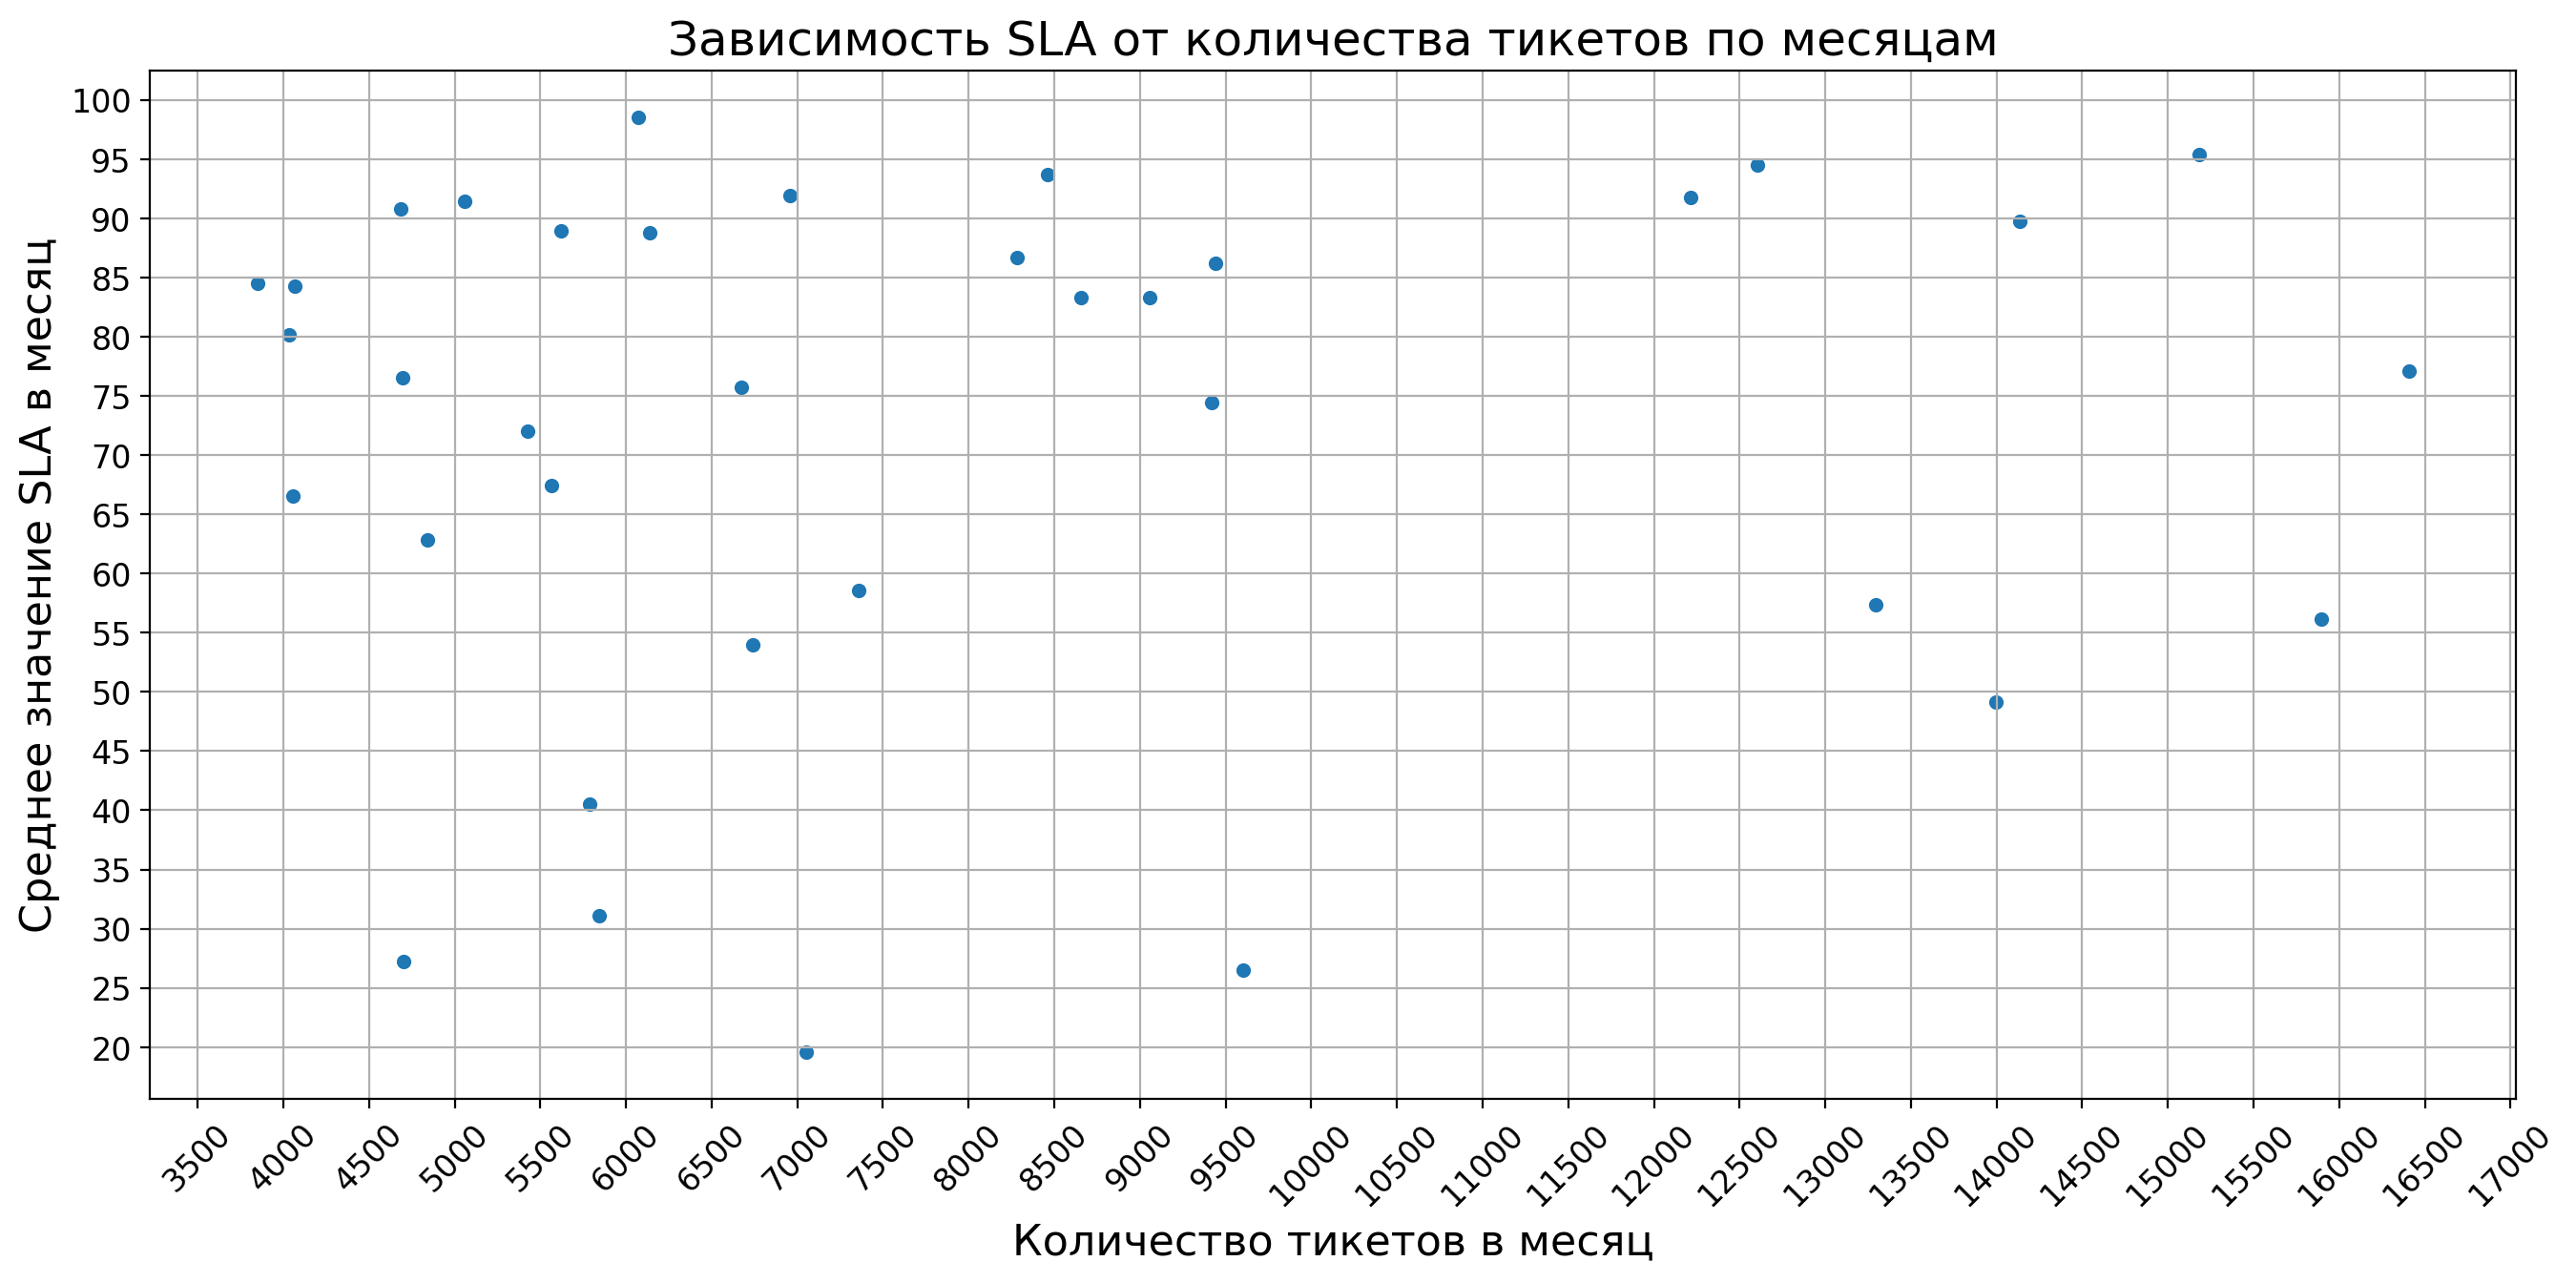

In [27]:
fig, ax = plt.subplots(figsize=(16, 7), dpi=200)
pivot_tickets.plot(x='count_of_tickets_sum', y='sla_mean', kind='scatter', alpha=1, ax=ax)
ax.set_title('Зависимость SLA от количества тикетов по месяцам', fontsize=18)
ax.set_xlabel('Количество тикетов в месяц', fontsize=16)
ax.set_ylabel('Среднее значение SLA в месяц', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.xaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_major_locator(MultipleLocator(5))
plt.xticks(rotation=45)
ax.grid(True)
plt.show()

#### Посчитаем коэффициент корреляции Пирсона между SLA от количеством тикетов по месяцам

In [28]:
round(pivot_tickets['count_of_tickets_sum'].corr(pivot_tickets['sla_mean']), 2)

0.06

### Выводы по исследовательскому анализу данных

1. Данные о тикетах и SLA службы поддержки представлены за 2022 - 2024 год за все месяцы.
2. В один момент времени в техническую поддержку приходило до 15 обращений.
3. Среднее значение SLA по тикетам за весь период наблюдений составляет 72.81%. Есть тикеты где SLA было равно нулю.
4. В течении года нагрузка неравномерна. В 2022 году максимальное количество обращений было зафиксировано в марте (6740) с последующим снижением до июля (4035). Далее наблюдаем снова рост обращения до ноября (7054) с последующим снижением в декабре. Данное поведение можно объяснить фактором сезонности. Деловая активность летом падает и может быть связана с сезоном отпусков во многих компаниях и учебных заведениях и начинает возрастать после возвращения из отпусков и начала учебного года.
6. Далее с апреля 2023 года наблюдаем резкий рост нагрузки до октября 2023 (15893) и держится на данном уровне до февраля 2024 с последующим падением до июня 2024 (6956) с последующим ростом до августа 2024 (9059) и последующим спадом до конца года. Данное поведение можно связать с появлением дополнительных факторов помимо сезонности: ввод нового продукта, рост числа продаж продуктов, вход крупного клиента с большим количеством пользователей. В связи с этим нагрузка могла вырасти и затем уже вернуться на практически прежние уровни когда была обучена большая часть пользователей и количество вопросов в поддержку было снижено.
7. Если сравнить между собой нагрузку за каждый год в совокупности, то мы наблюдаем четкий рост нагрузки со средним значением 5442.67 обращений в 2022 и году и 10039.83 обращений в 2024.
8. С точки зрения SLA за весь период наблюдений никакого направленного тренда отметить нельзя. Это видно как графику средних значений по годам, так и по диаграмме рассеяния зависимости SLA от количества тикетов по месяцам. Также на это указывает коэффициент корелляции Пирсона между SLA от количеством тикетов по месяцам, который составляет 0.06. То есть при одной и той же нагрузке мы можем наблюдать как низкое так и высокое значение SLA. Также мы можем наблюдать одинаково высокое значение SLA при минимальных и максимальных значениях нагрузки за месяц. Таким образом, нельзя сказать, что увеличение нагрузки приводит к снижению значения SLA обработки тикетов. Это значит, что снижение значений SLA обработки тикетов следует связывать с другими факторами.
9. По производительности операторов данные представлены за 2024 год.
10. Всего представлены данные по 15 операторам. По 8 операторам из них есть данные за весь 2024 год.
11. Среди операторов по которым есть данные за 2024 за весь год в топ 3 входит Настя (20976 тикетов или в среднем 1748 тикетов в месяц), Лера (18670 тикетов или в среднем 1555.83 тикетов в месяц) и Ксюша (16592 тикета или в среднем 1382.67 тикетов в месяц).

## Общие выводы

### Проведенная работа над данными

1. Изучена общая информация о представленных данных.
2. В данных были проанализированы пропуски, дубликаты и категориальные значения.
3. Для последующего анализа были созданы дополнильнительные столбцы.

### Выводы по итогу анализа данных

1. Данные о тикетах и SLA службы поддержки представлены за 2022 - 2024 год за все месяцы.
2. В течении года нагрузка неравномерна. Нагрузка растет в зимние месяцы, падает ближе к лету и снова начинает расти ближе к осени. Данное поведение можно объяснить фактором сезонности. Деловая активность летом падает и может быть связана с сезоном отпусков во многих компаниях и учебных заведениях и начинает возрастать после возвращения из отпусков и начала учебного года.
3. В 2023 году наблюдаем резкий рост нагрузки, которая упадет только в середине июня 2024. Данное поведение можно связать с появлением дополнительных факторов помимо сезонности: ввод нового продукта, рост числа продаж продуктов, вход крупного клиента с большим количеством пользователей.
4. Наблюдаем четкий рост нагрузки с 2022 по 2024 год.
5. С точки зрения SLA за весь период наблюдений никакого направленного тренда отметить нельзя. Также нельзя сказать, что увеличение нагрузки приводит к снижению значения SLA обработки тикетов.